In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import cv2

In [40]:
def BC(hist1, hist2):
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    BC = np.sum(np.sqrt(hist1 * hist2))
    return BC



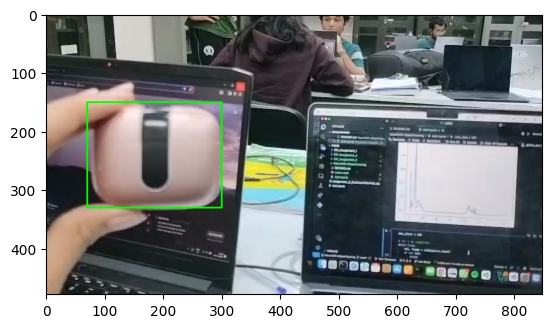

In [41]:
# open video file (use VideoCapture, not imread)
vidCapture = cv2.VideoCapture('case.mp4')

ret, frame = vidCapture.read()
x = 70
y = 150
w = 230
h = 180
track_window = (x, y, w, h)

cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.show()

# vidCapture = cv2.VideoCapture('case.mp4')
# ret, frame = vidCapture.read()

# # Let user drag a rectangle around the object
# x, y, w, h = cv2.selectROI("Select Object", frame, fromCenter=False)
# cv2.destroyWindow("Select Object")

# track_window = (x, y, w, h)


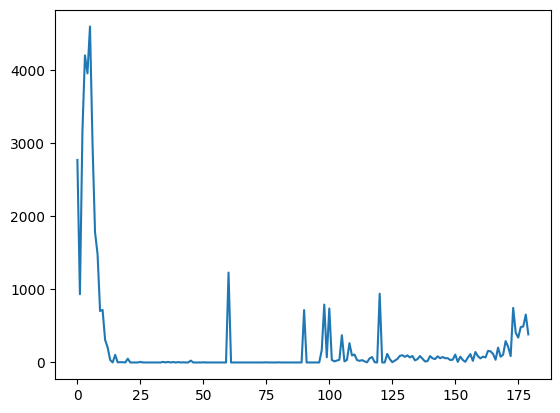

In [42]:
roi = frame[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
hist_target = cv2.calcHist([hsv_roi], [0], None, [180], [0, 180])
# cv2.normalize(hist_target, hist_target, 0, 1, cv2.NORM_MINMAX)

plt.plot(hist_target)
plt.show()


In [43]:
max_iters = 100

# for i in range(10):
while True:
    ret, frame = vidCapture.read()
    if not ret:
        break
    

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    curr_hist = cv2.calcHist([hsv], [0], None, [180], [0, 180])
    cv2.normalize(curr_hist, curr_hist, 0, 1, cv2.NORM_MINMAX)
    similarity = BC(hist_target, curr_hist)
    prob_map = cv2.calcBackProject([hsv], [0], hist_target, [0, 180], 1)

    # --- Mean Shift iteration ---
    for _ in range(max_iters):
        x, y, w, h = track_window
        window = prob_map[y:y+h, x:x+w]

        coords_y, coords_x = np.mgrid[0:h, 0:w]
        weights = window.astype(np.float32)
        total = np.sum(weights) + 1e-5

        x_shift = np.sum(coords_x * weights) / total
        y_shift = np.sum(coords_y * weights) / total

        new_x = int(x + (x_shift - w/2))
        new_y = int(y + (y_shift - h/2))
        
        # --- Clamp to frame boundaries ---
        height, width = frame.shape[:2]
        new_x = max(0, min(new_x, width  - w))
        new_y = max(0, min(new_y, height - h))

        # Check convergence
        if abs(new_x - x) < 1 and abs(new_y - y) < 1:
            break
        track_window = (new_x, new_y, w, h)

    # --- Draw result ---
    x, y, w, h = track_window
    result = cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.imshow('Tracking', result)

    if cv2.waitKey(30) & 0xFF == 27:
        break

vidCapture.release()
cv2.destroyAllWindows()
cv2.waitKey(1)


/var/folders/55/yf77rt6x0qx69kxlcgdk4zpw0000gn/T/ipykernel_27807/411155720.py:4: RuntimeWarning: invalid value encountered in sqrt
  BC = np.sum(np.sqrt(hist1 * hist2))


-1